# 🔍 Exploratory Data Analysis — Netflix Content Catalog

A narrative walk-through of the cleaned, normalized catalog (**one row per title**, ~8,800 titles). The heavy lifting lives in the reusable module `src/analysis/eda.py` — this notebook is the *story* around it: load the data, look at distributions, trends, outliers, and the few numeric relationships, and write down what we learn.

Distributions and outliers are computed in **pandas** on the `titles` table; the ranking charts reuse the **Milestone 6 SQL analytics layer** — EDA builds on the stack below it instead of re-deriving those aggregates.

In [1]:
%matplotlib inline
import sqlite3
import sys, pathlib

# Make `src` importable whether the notebook runs from the repo root or notebooks/.
_p = pathlib.Path.cwd()
while not (_p / 'src').is_dir() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

import pandas as pd
from IPython.display import display

from src import config
from src.analysis import eda, sql_analytics

sql_analytics.ensure_database()               # M5 ETL builds the DB if missing
conn = sqlite3.connect(config.DATABASE_PATH)  # read-only session connection
titles = eda.load_titles(conn)
print(f'Loaded {len(titles):,} titles into a DataFrame')
titles.head()

2026-08-03 13:09:56 | INFO     | src.analysis.eda | Loaded 8807 titles for EDA


Loaded 8,807 titles into a DataFrame


,show_id,type,title,date_added,year_added,month_added,release_year,rating,duration_value,duration_unit,description
0,s1,Movie,Dick Johnson Is Dead,2021-09-25,2021.0,9.0,2020,PG-13,90,Minutes,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,2021-09-24,2021.0,9.0,2021,TV-MA,2,Seasons,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,2021-09-24,2021.0,9.0,2021,TV-MA,1,Seasons,To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,2021-09-24,2021.0,9.0,2021,TV-MA,1,Seasons,"Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,2021-09-24,2021.0,9.0,2021,TV-MA,2,Seasons,In a city of coaching centers known to train I...


## 1. Catalog composition

First question for any catalog: **what is it made of?** How many Movies vs TV Shows, and how are titles rated?

,n_titles
type,
Movie,6131
TV Show,2676


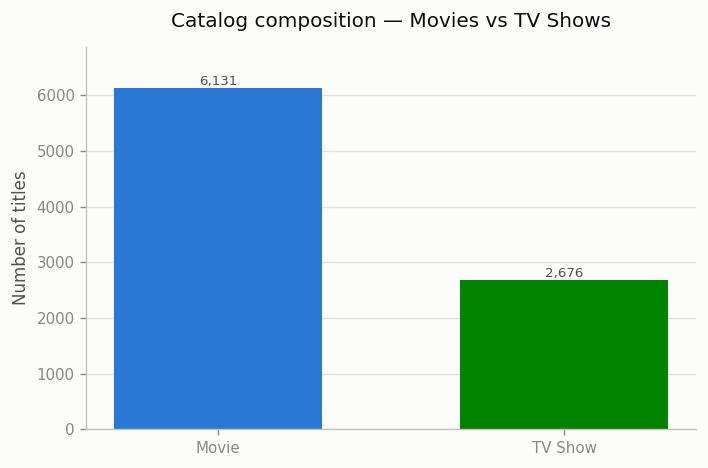

In [2]:
display(titles['type'].value_counts().rename('n_titles').to_frame())
eda.plot_type_split(titles);

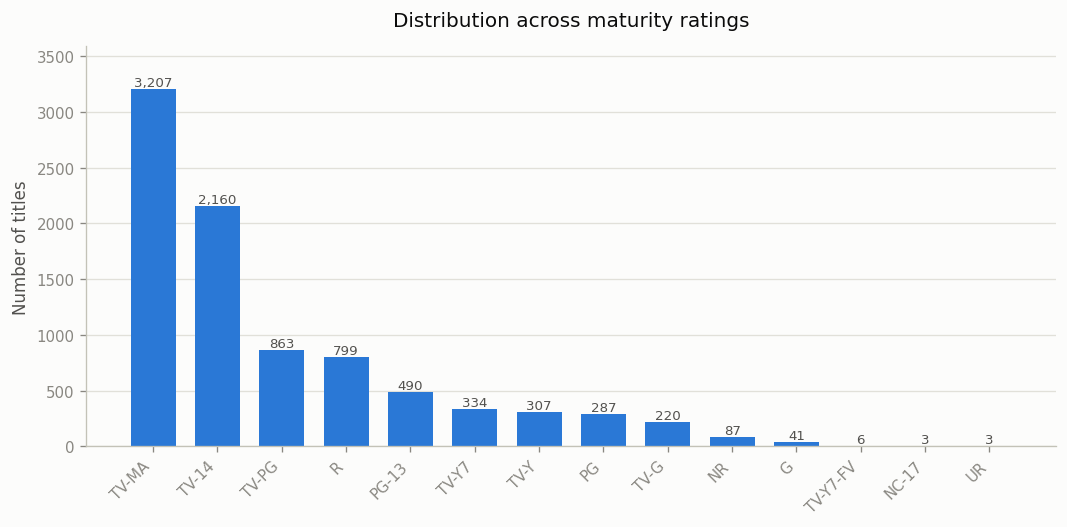

In [3]:
eda.plot_rating_distribution(titles);

**Read:** the catalog is movie-heavy (~70/30), and maturity ratings skew adult — `TV-MA` and `TV-14` alone are ~6 in 10 titles.

## 2. Content age

`release_year` tells us how old the *content* is (distinct from when it was *added* to Netflix — that's the next section).

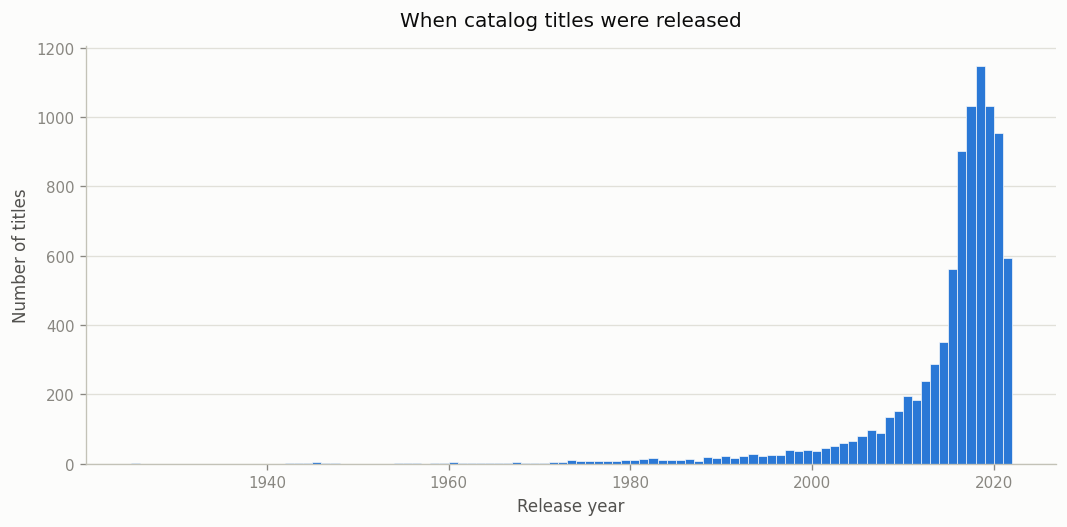

In [4]:
eda.plot_release_year_hist(titles);

**Read:** strongly left-skewed — most titles are from the 2010s onward, with a long thin tail of older classics back to the 1920s.

## 3. Growth over time

When did titles *join* the catalog, and how does the Movie/TV split evolve?

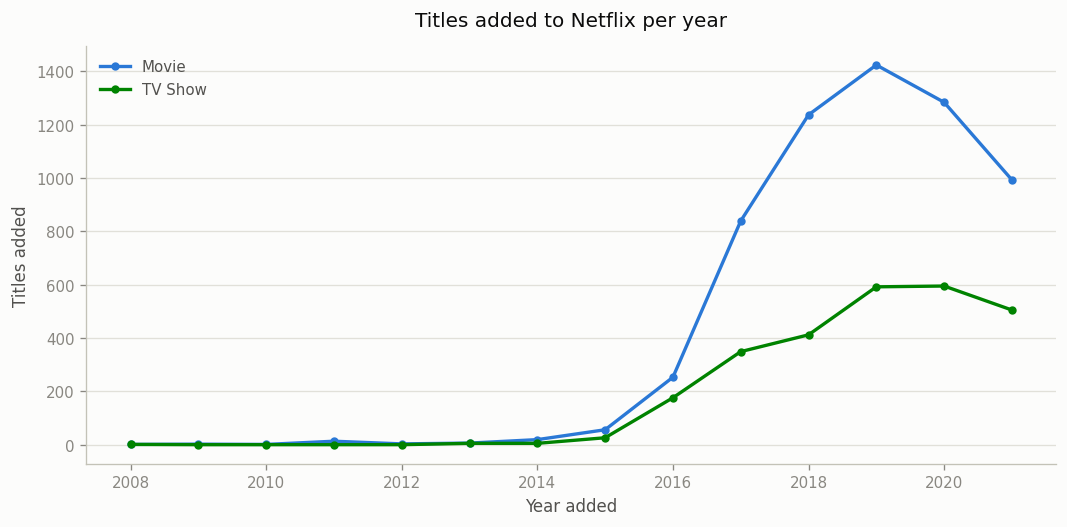

In [5]:
eda.plot_titles_added_over_time(titles);

**Read:** additions accelerate sharply after 2015 and peak around 2019. TV Show additions climb faster than Movies late in the window, narrowing the gap — the catalog is diversifying toward series.

## 4. Top contributors (reusing the SQL layer)

For the ranking questions — top genres and countries — we call straight into the Milestone 6 queries rather than re-writing the bridge-table aggregation.

,genre_name,n_titles
0,International Movies,2752
1,Dramas,2427
2,Comedies,1674
3,International TV Shows,1351
4,Documentaries,869


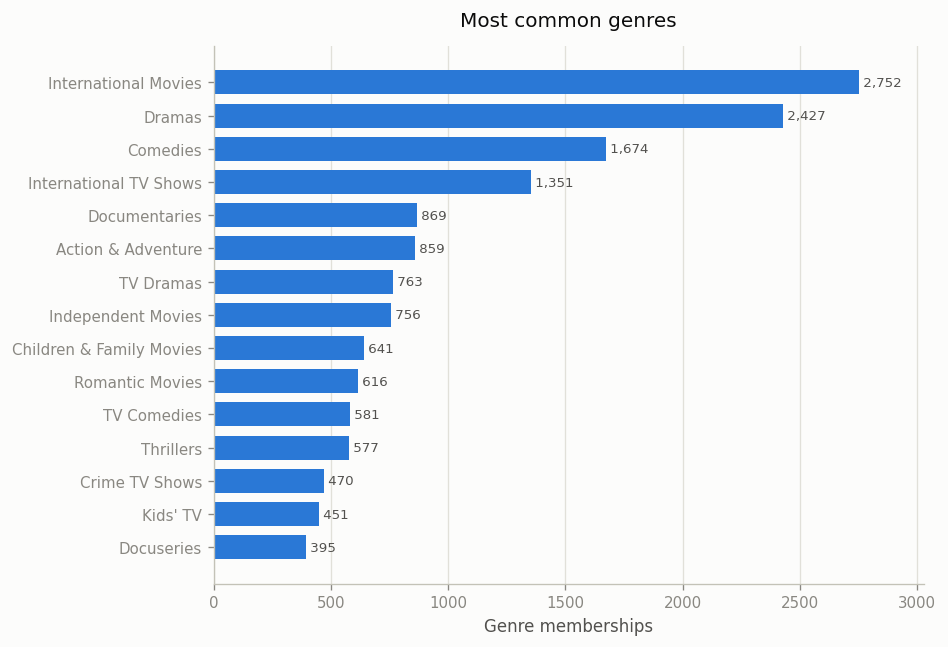

In [6]:
display(sql_analytics.run_query('top_genres', conn).head())
eda.plot_top_genres(conn);

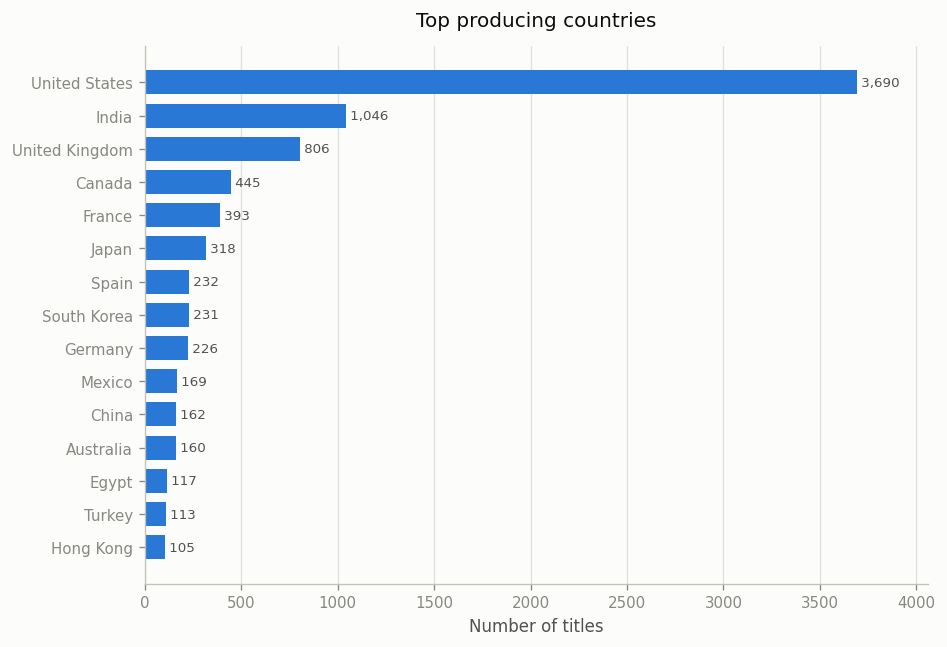

In [7]:
eda.plot_top_countries(conn);

**Read:** *International Movies*, *Dramas*, and *Comedies* dominate genres; the US, India, and the UK lead production. Genre counts are *memberships* (a title has several genres), not distinct titles.

## 5. Movie runtime & outliers

The one rich numeric field is movie runtime. We summarize it and flag outliers with the **1.5×IQR** rule.

,value
n_movies,6131.0
q1,87.0
median,98.0
q3,114.0
iqr,27.0
lower_bound,46.5
upper_bound,154.5
n_outliers,450.0
min,3.0
max,312.0


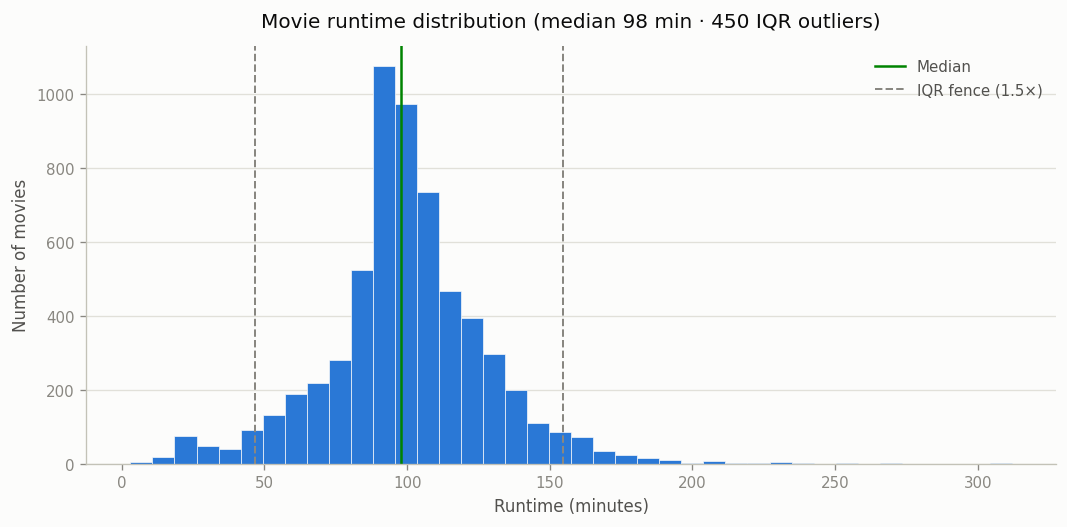

In [8]:
stats = eda.runtime_outliers(titles)
display(pd.Series(stats).to_frame('value'))
eda.plot_runtime_distribution(titles);

**Read:** runtimes are roughly bell-shaped around a ~98-minute median. The IQR fence flags a few hundred outliers — very short specials/shorts on the left and a handful of long films on the right. These are *legitimate* extremes, not data errors, so we keep them and simply note them.

## 6. Numeric relationships

With only three numeric fields (and runtime meaningful only for movies), a correlation matrix is quick — and the *absence* of strong correlation is itself the finding.

,release_year,year_added,runtime_min
release_year,1.00,0.04,-0.21
year_added,0.04,1.00,0.13
runtime_min,-0.21,0.13,1.00


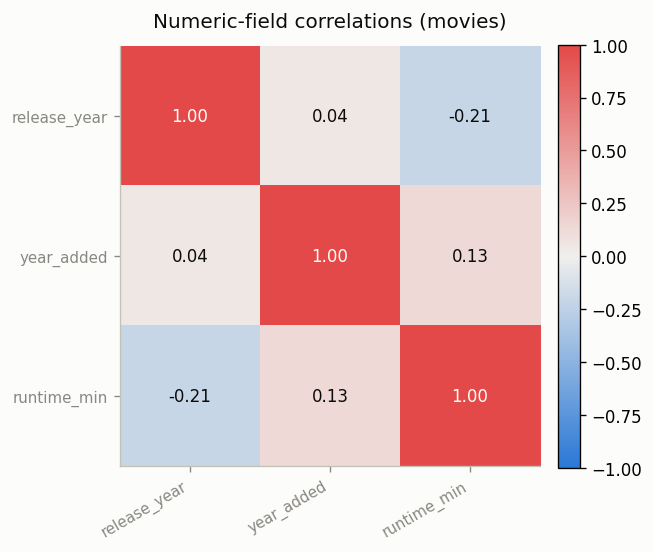

In [9]:
display(eda.correlation_matrix(titles))
eda.plot_correlation_heatmap(titles);

**Read:** correlations are weak — newer movies trend *slightly* shorter, nothing more. This catalog's signal lives in its **categorical** dimensions (type, genre, country, rating), not in numeric regression. That shapes the rest of the project: KPIs and the recommender lean on categories, not continuous predictors.

## 7. Numeric summary & takeaways


In [10]:
eda.numeric_summary(titles)

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
year_added,8797.0,2018.871888,1.574243,2008.0,2018.0,2019.0,2020.0,2021.0
duration_value,8807.0,69.848530,50.806431,1.0,2.0,88.0,106.0,312.0


### Key takeaways
1. **~70% Movies / 30% TV Shows**, skewing toward mature ratings.
2. Content is **recent** (left-skewed release years) and was added in a **post-2015 surge** that peaked ~2019.
3. TV is the **faster-growing** format late in the window.
4. Movie runtimes cluster near a **98-min median**; IQR outliers are real extremes worth keeping.
5. The data is **categorical-first** — weak numeric correlations mean insight comes from genre/country/type, which drives the KPI, recommender, and dashboard milestones ahead.

In [11]:
conn.close()